<a href="https://colab.research.google.com/github/Kan1shka/generate-timetable-using-GI-and-Fuzzy-Network/blob/main/timetable_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Intelligent Academic Timetable System
### Genetic Algorithm + Fuzzy Logic Optimization
---
**Version 2 — Enhanced with Visual Grid | Conflict Checker | Performance Metrics | Fitness Graph | Day+Slot System**

| Feature | V1 (Before) | V2 (After) |
|---|---|---|
| Time representation | Slot ID only | Day + Slot + Time label |
| Max classes/teacher/day | 3 | **4 (configurable)** |
| Timetable output | Raw DataFrame | **Colour-coded grid chart** |
| Conflict detection | Basic penalty only | **Full conflict checker report** |
| Performance report | 5 metrics | **8 metrics + convergence gen** |
| Fitness plot | Simple 2-panel | **Annotated + shaded area + convergence marker** |
| Mutation operators | 3 actions | **5 actions (day_slot swap added)** |

## ⚙️ Step 0 — Install Dependencies

In [ ]:
!pip install pandas openpyxl scikit-fuzzy numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 34.8 MB/s eta 0:00:00


## 📂 Step 1 — Upload Dataset
Upload your `dataset_for_timetable.xlsx` file when prompted below.  
The file must contain four sheets: **Teachers**, **subjects**, **Rooms**, **sections**.

In [ ]:
from google.colab import files
uploaded = files.upload()
filepath = list(uploaded.keys())[0]
print(f"✅ Uploaded: {filepath}")

Saving dataset for timetable.xlsx to dataset for timetable (1).xlsx
✅ Uploaded: dataset for timetable (1).xlsx


## 📦 Step 2 — Imports & Global Setup

In [ ]:
import pandas as pd
import numpy as np
import random, copy, time, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
warnings.filterwarnings("ignore")

try:
    import skfuzzy as fuzz
    from skfuzzy import control as ctrl
    SKFUZZY_AVAILABLE = True
    print("✅ scikit-fuzzy loaded")
except ImportError:
    SKFUZZY_AVAILABLE = False
    print("[INFO] scikit-fuzzy not found – using built-in fuzzy logic.")

✅ scikit-fuzzy loaded


## 🔧 Step 3 — Configuration
> **Edit these values to customise the system before running.**

In [ ]:
# ── Time ──────────────────────────────────────────────────────────────────
START_TIME    = 8       # 08:00
END_TIME      = 15      # 15:00
BREAK_START   = 12      # break starts
BREAK_END     = 13      # break ends
SLOT_DURATION = 1       # hours per slot

# ── Working days ──────────────────────────────────────────────────────────────
WORKING_DAYS  = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]

# ── Hard limits ───────────────────────────────────────────────────────────────
MAX_TEACHER_CLASSES_PER_DAY = 4   # max classes any teacher can have in one day

# ── GA hyper-parameters ───────────────────────────────────────────────────────
POP_SIZE        = 60
NUM_GENERATIONS = 150
CROSSOVER_RATE  = 0.8
MUTATION_RATE   = 0.15
ELITE_SIZE      = 6
HARD_PENALTY    = 100

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("✅ Configuration set")

✅ Configuration set


## ⏰ Step 4 — Day + Slot System *(Upgrade #5)*
**Before (V1):** Slot was just an integer ID with no day context.  
**After (V2):** Every slot is a `(Day, Slot_ID) → Time` pair.  
Working days are user-configurable; slots are generated dynamically per day.

In [ ]:
def generate_time_slots(start=START_TIME, end=END_TIME,
                         break_start=BREAK_START, break_end=BREAK_END,
                         duration=SLOT_DURATION):
    slots, sid = [], 1
    t = start
    while t + duration <= end:
        if not (t >= break_start and t < break_end):
            slots.append({
                "Slot_ID": sid,
                "Start":   t,
                "End":     t + duration,
                "Label":   f"{t:02d}:00-{t+duration:02d}:00",
            })
            sid += 1
        t += duration
    return pd.DataFrame(slots)

def generate_day_slot_index(working_days, time_slots_df):
    index = {}
    for day in working_days:
        for _, row in time_slots_df.iterrows():
            index[(day, int(row["Slot_ID"]))] = row["Label"]
    return index

TIME_SLOTS_DF   = generate_time_slots()
NUM_SLOTS       = len(TIME_SLOTS_DF)
DAY_SLOT_INDEX  = generate_day_slot_index(WORKING_DAYS, TIME_SLOTS_DF)
SLOT_LABEL      = TIME_SLOTS_DF.set_index("Slot_ID")["Label"].to_dict()
SLOT_START      = TIME_SLOTS_DF.set_index("Slot_ID")["Start"].to_dict()

print("=" * 55)
print("  TIME SLOT CONFIGURATION")
print("=" * 55)
print(f"  Working days       : {', '.join(WORKING_DAYS)}")
print(f"  Slots per day      : {NUM_SLOTS}  ({SLOT_LABEL[1]} → {SLOT_LABEL[NUM_SLOTS]})")
print(f"  Break window       : {BREAK_START:02d}:00 – {BREAK_END:02d}:00 (excluded)")
print(f"  Max cls/teacher/day: {MAX_TEACHER_CLASSES_PER_DAY}")
print("=" * 55)
print()
print(TIME_SLOTS_DF.to_string(index=False))

  TIME SLOT CONFIGURATION
  Working days       : Monday, Tuesday, Wednesday, Thursday, Friday
  Slots per day      : 6  (08:00-09:00 → 14:00-15:00)
  Break window       : 12:00 – 13:00 (excluded)
  Max cls/teacher/day: 4

 Slot_ID  Start  End       Label
       1      8    9 08:00-09:00
       2      9   10 09:00-10:00
       3     10   11 10:00-11:00
       4     11   12 11:00-12:00
       5     13   14 13:00-14:00
       6     14   15 14:00-15:00


## 📊 Step 5 — Data Loading & Preprocessing

In [ ]:
def load_data(filepath):
    xl = pd.read_excel(filepath, sheet_name=None)
    return xl["Teachers"], xl["subjects"], xl["Rooms"], xl["sections"]

def preprocess(teachers, subjects, rooms, sections):
    teachers = teachers.copy()
    teachers["Availability"]        = teachers["Availability"].fillna("Full")
    teachers["Subjects"]            = teachers["Subjects"].str.strip()
    teachers["Max_Classes_Per_Day"]  = (
        teachers["Max_Classes_Per_Day"]
        .fillna(MAX_TEACHER_CLASSES_PER_DAY).astype(int)
        .clip(upper=MAX_TEACHER_CLASSES_PER_DAY))
    teachers["Preferred_Slots"] = teachers["Preferred_Slots"].astype(str).apply(
        lambda x: [int(s.strip()) for s in x.split(",") if s.strip().isdigit()])

    subject_teacher_map = {}
    for _, row in teachers.iterrows():
        for subj in row["Subjects"].split(","):
            subj = subj.strip()
            subject_teacher_map.setdefault(subj, []).append(row["Teacher_ID"])

    subjects = subjects.copy()
    subjects["Type"] = (subjects["Type"].str.strip().str.capitalize()
                         .replace({"theory": "Theory", "lab": "Lab"}))
    subjects["Classes_Per_Week"] = subjects["Classes_Per_Week"].fillna(2).astype(int)
    subject_map = subjects.set_index("Subject_Name").to_dict("index")

    rooms = rooms.copy()
    rooms["Type"]  = rooms["Type"].str.strip().str.capitalize()
    class_rooms    = rooms[rooms["Type"] == "Class"]["Room_ID"].tolist()
    lab_rooms      = rooms[rooms["Type"] == "Lab"]["Room_ID"].tolist()

    sections = sections.copy()
    sections["Subjects"] = sections["Subjects"].apply(
        lambda x: [s.strip() for s in str(x).split(",")])

    return (teachers, subjects, rooms, sections,
            subject_teacher_map, subject_map, class_rooms, lab_rooms)

teachers, subjects, rooms, sections = load_data(filepath)
(teachers, subjects, rooms, sections,
 subject_teacher_map, subject_map,
 class_rooms, lab_rooms) = preprocess(teachers, subjects, rooms, sections)

print(f"✅ Teachers  : {len(teachers)}")
print(f"✅ Subjects  : {len(subjects)}")
print(f"✅ Rooms     : {len(rooms)}  (Class: {len(class_rooms)}, Lab: {len(lab_rooms)})")
print(f"✅ Sections  : {len(sections)}")

✅ Teachers  : 30
✅ Subjects  : 15
✅ Rooms     : 10  (Class: 5, Lab: 5)
✅ Sections  : 10


## 🧬 Step 6 — Chromosome Representation
Each chromosome = one complete weekly timetable.  
Each gene = one scheduled class: `{section, subject, teacher, room, day, slot, time}`

In [ ]:
def build_required_classes(sections, subjects_df, subject_map,
                            subject_teacher_map, class_rooms, lab_rooms):
    required = []
    for _, sec in sections.iterrows():
        for subj_name in sec["Subjects"]:
            if subj_name not in subject_map:
                continue
            info         = subject_map[subj_name]
            s_type       = info["Type"]
            cpw          = info["Classes_Per_Week"]
            teachers_for = subject_teacher_map.get(subj_name, [])
            rooms_for    = lab_rooms if s_type == "Lab" else class_rooms
            if not teachers_for or not rooms_for:
                continue
            for _ in range(cpw):
                required.append({
                    "section":       sec["Section_ID"],
                    "subject":       subj_name,
                    "type":          s_type,
                    "teachers_pool": teachers_for,
                    "rooms_pool":    rooms_for,
                })
    return required

def random_gene(entry):
    day  = random.choice(WORKING_DAYS)
    slot = random.randint(1, NUM_SLOTS)
    return {
        "section": entry["section"],
        "subject": entry["subject"],
        "type":    entry["type"],
        "teacher": random.choice(entry["teachers_pool"]),
        "room":    random.choice(entry["rooms_pool"]),
        "day":     day,
        "slot":    slot,
        "time":    SLOT_LABEL[slot],
    }

def random_chromosome(required_classes):
    return [random_gene(e) for e in required_classes]

required_classes = build_required_classes(
    sections, subjects, subject_map,
    subject_teacher_map, class_rooms, lab_rooms)
print(f"✅ {len(required_classes)} class sessions to schedule across "      f"{len(WORKING_DAYS)} days × {NUM_SLOTS} slots")

✅ 57 class sessions to schedule across 5 days × 6 slots


## 🌫️ Step 7 — Fuzzy Logic Module
Evaluates **soft constraints**: teacher workload balance, preference satisfaction, consecutive lecture avoidance.

In [ ]:
def build_fuzzy_system_skfuzzy():
    wl   = ctrl.Antecedent(np.arange(0, 11, 1), "workload")
    pref = ctrl.Antecedent(np.arange(0, 11, 1), "preference")
    bal  = ctrl.Antecedent(np.arange(0, 11, 1), "balance")
    q    = ctrl.Consequent(np.arange(0, 11, 1), "quality")
    for v in [wl, pref, bal, q]:
        v.automf(3)
    rules = [
        ctrl.Rule(wl["poor"]    & pref["good"],    q["good"]),
        ctrl.Rule(wl["average"] & pref["average"], q["average"]),
        ctrl.Rule(wl["good"]    & bal["good"],     q["good"]),
        ctrl.Rule(wl["good"]    & pref["poor"],    q["poor"]),
        ctrl.Rule(bal["poor"],                      q["poor"]),
    ]
    return ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

FUZZY_SIM = build_fuzzy_system_skfuzzy() if SKFUZZY_AVAILABLE else None

def _tri(x, a, b, c):
    if x <= a or x >= c: return 0.0
    return (x - a) / (b - a) if x <= b else (c - x) / (c - b)

def fuzzy_score_manual(wl_score, pref_score, bal_score):
    good = max(_tri(wl_score,0,0,5)*_tri(pref_score,5,10,10),
               _tri(wl_score,3,5,7)*_tri(bal_score,5,10,10))
    avg  = _tri(wl_score,3,5,7) * (1 - _tri(pref_score,0,0,5))
    poor = max(_tri(wl_score,5,10,10)*_tri(pref_score,0,0,5),
               _tri(bal_score,0,0,5))
    return (good*8 + avg*5 + poor*2) / (good + avg + poor + 1e-9)

def evaluate_fuzzy(chromosome, teachers_df):
    loads, pref_hits, total = {}, 0, len(chromosome)
    schedule = defaultdict(list)
    for gene in chromosome:
        tid = gene["teacher"]
        loads[tid] = loads.get(tid, 0) + 1
        row = teachers_df[teachers_df["Teacher_ID"] == tid]
        if not row.empty and gene["slot"] in row.iloc[0]["Preferred_Slots"]:
            pref_hits += 1
        schedule[(tid, gene["day"])].append(gene["slot"])
    consec = sum(
        1 for slots in schedule.values()
        for a, b in zip(sorted(slots), sorted(slots)[1:]) if b == a + 1)
    if total == 0: return 5.0
    avg_load   = sum(loads.values()) / len(loads)
    imbalance  = (max(loads.values()) - avg_load) / max(avg_load, 1)
    wl_score   = min(10, imbalance * 10)
    pref_score = (pref_hits / total) * 10
    bal_score  = max(0, 10 - (consec / total) * 20)
    if SKFUZZY_AVAILABLE and FUZZY_SIM:
        try:
            FUZZY_SIM.input["workload"]   = wl_score
            FUZZY_SIM.input["preference"] = pref_score
            FUZZY_SIM.input["balance"]    = bal_score
            FUZZY_SIM.compute()
            return FUZZY_SIM.output["quality"]
        except Exception: pass
    return fuzzy_score_manual(wl_score, pref_score, bal_score)

print("✅ Fuzzy logic module ready")

✅ Fuzzy logic module ready


## 🎯 Step 8 — Conflict Detection & Fitness Function
**Before (V1):** Violations counted inline inside fitness only.  
**After (V2):** `detect_conflicts()` is a standalone engine reused by both fitness and the Conflict Checker report.

In [ ]:
def detect_conflicts(chromosome):
    teacher_map  = defaultdict(list)
    room_map     = defaultdict(list)
    section_map  = defaultdict(list)
    teacher_day  = defaultdict(int)
    for i, gene in enumerate(chromosome):
        key = (gene["day"], gene["slot"])
        teacher_map[(gene["teacher"], *key)].append(i)
        room_map   [(gene["room"],    *key)].append(i)
        section_map[(gene["section"], *key)].append(i)
        teacher_day[(gene["teacher"],  gene["day"])] += 1
    teacher_clashes = sum(max(0, len(v)-1) for v in teacher_map.values()  if len(v)>1)
    room_clashes    = sum(max(0, len(v)-1) for v in room_map.values()     if len(v)>1)
    section_clashes = sum(max(0, len(v)-1) for v in section_map.values()  if len(v)>1)
    day_violations  = sum(max(0, cnt - MAX_TEACHER_CLASSES_PER_DAY)
                          for cnt in teacher_day.values())
    total = teacher_clashes + room_clashes + section_clashes + day_violations
    return {"total": total, "teacher_clashes": teacher_clashes,
            "room_clashes": room_clashes, "section_clashes": section_clashes,
            "day_violations": day_violations}

def fitness(chromosome, teachers_df):
    c = detect_conflicts(chromosome)
    hard_score  = max(0, 1000 - c["total"] * HARD_PENALTY)
    fuzzy_score = evaluate_fuzzy(chromosome, teachers_df)
    return hard_score + fuzzy_score * 10, c["total"]

print("✅ Conflict detection and fitness function ready")

✅ Conflict detection and fitness function ready


## 🔀 Step 9 — Genetic Algorithm Operators
**Before (V1):** 3 mutation actions (slot, room, teacher, day).  
**After (V2):** Added `day_slot` mutation (swaps day and slot simultaneously for faster escape from local optima).

In [ ]:
def tournament_select(population, scores, k=3):
    idxs = random.sample(range(len(population)), k)
    return copy.deepcopy(population[max(idxs, key=lambda i: scores[i])])

def crossover(p1, p2):
    if random.random() > CROSSOVER_RATE or len(p1) < 2:
        return copy.deepcopy(p1), copy.deepcopy(p2)
    pt = random.randint(1, len(p1)-1)
    return p1[:pt]+p2[pt:], p2[:pt]+p1[pt:]

def mutate(chrom, required):
    for i in range(len(chrom)):
        if random.random() < MUTATION_RATE:
            action = random.choice(["slot", "day", "room", "teacher", "day_slot"])
            entry  = required[i]
            if action == "slot":
                ns = random.randint(1, NUM_SLOTS)
                chrom[i]["slot"] = ns; chrom[i]["time"] = SLOT_LABEL[ns]
            elif action == "day":
                chrom[i]["day"] = random.choice(WORKING_DAYS)
            elif action == "day_slot":
                ns = random.randint(1, NUM_SLOTS)
                chrom[i]["day"]  = random.choice(WORKING_DAYS)
                chrom[i]["slot"] = ns; chrom[i]["time"] = SLOT_LABEL[ns]
            elif action == "room":
                chrom[i]["room"] = random.choice(entry["rooms_pool"])
            elif action == "teacher":
                chrom[i]["teacher"] = random.choice(entry["teachers_pool"])
    return chrom

print("✅ GA operators ready (5 mutation actions)")

✅ GA operators ready (5 mutation actions)


## 🧬 Step 10 — Run Genetic Algorithm

In [ ]:
def run_genetic_algorithm(required_classes, teachers_df):
    print(f"{'='*60}")
    print("  GENETIC ALGORITHM")
    print(f"{'='*60}")
    print(f"  Population : {POP_SIZE}   Generations : {NUM_GENERATIONS}")
    print(f"  Crossover  : {CROSSOVER_RATE}     Mutation    : {MUTATION_RATE}")
    print(f"  Elite size : {ELITE_SIZE}   Max cls/day : {MAX_TEACHER_CLASSES_PER_DAY}")
    print(f"{'='*60}\n")

    population = [random_chromosome(required_classes) for _ in range(POP_SIZE)]
    best_fitness_hist, avg_fitness_hist, best_violations_hist = [], [], []
    best_chrom, best_fit = None, -1
    start_t = time.time()

    for gen in range(NUM_GENERATIONS):
        evaluated = [fitness(ch, teachers_df) for ch in population]
        scores    = [e[0] for e in evaluated]
        viols     = [e[1] for e in evaluated]
        best_idx  = int(np.argmax(scores))
        gen_best  = scores[best_idx]
        gen_avg   = float(np.mean(scores))
        best_fitness_hist.append(gen_best)
        avg_fitness_hist.append(gen_avg)
        best_violations_hist.append(viols[best_idx])
        if gen_best > best_fit:
            best_fit   = gen_best
            best_chrom = copy.deepcopy(population[best_idx])
        if gen % 15 == 0 or gen == NUM_GENERATIONS - 1:
            elapsed = time.time() - start_t
            print(f"  Gen {gen:3d} | Fitness {gen_best:8.2f} | "                  f"Avg {gen_avg:8.2f} | Violations {viols[best_idx]:3d} | "                  f"Time {elapsed:.1f}s")
        if viols[best_idx] == 0 and gen_best >= 1090:
            print(f"\n  ✅ Early stop at generation {gen} – optimal reached.")
            pad = NUM_GENERATIONS - gen - 1
            best_fitness_hist    += [gen_best] * pad
            avg_fitness_hist     += [gen_avg]  * pad
            best_violations_hist += [0]        * pad
            break
        sorted_idx = sorted(range(POP_SIZE), key=lambda i: scores[i], reverse=True)
        new_pop    = [copy.deepcopy(population[i]) for i in sorted_idx[:ELITE_SIZE]]
        while len(new_pop) < POP_SIZE:
            c1, c2 = crossover(tournament_select(population, scores),
                                tournament_select(population, scores))
            new_pop += [mutate(c1, required_classes), mutate(c2, required_classes)]
        population = new_pop[:POP_SIZE]

    exec_time = time.time() - start_t
    print(f"\n  ✅ Done in {exec_time:.1f}s | Best fitness: {best_fit:.2f} | "          f"Violations: {best_violations_hist[-1]}")
    return (best_chrom, best_fitness_hist, avg_fitness_hist,
            best_violations_hist, exec_time)

(best_chrom, best_hist, avg_hist,
 viol_hist, exec_time) = run_genetic_algorithm(required_classes, teachers)

  GENETIC ALGORITHM
  Population : 60   Generations : 150
  Crossover  : 0.8     Mutation    : 0.15
  Elite size : 6   Max cls/day : 4

  Gen   0 | Fitness   262.54 | Avg    68.40 | Violations   8 | Time 1.5s
  Gen  15 | Fitness   866.67 | Avg   484.99 | Violations   2 | Time 23.1s
  Gen  30 | Fitness  1062.27 | Avg   597.45 | Violations   0 | Time 43.7s
  Gen  45 | Fitness  1068.10 | Avg   695.19 | Violations   0 | Time 64.6s
  Gen  60 | Fitness  1077.07 | Avg   632.83 | Violations   0 | Time 85.8s
  Gen  75 | Fitness  1082.31 | Avg   667.05 | Violations   0 | Time 106.1s
  Gen  90 | Fitness  1083.05 | Avg   703.23 | Violations   0 | Time 126.8s
  Gen 105 | Fitness  1083.26 | Avg   705.30 | Violations   0 | Time 147.9s
  Gen 120 | Fitness  1083.33 | Avg   698.24 | Violations   0 | Time 167.8s
  Gen 135 | Fitness  1083.33 | Avg   702.18 | Violations   0 | Time 188.8s
  Gen 149 | Fitness  1083.33 | Avg   695.11 | Violations   0 | Time 207.5s

  ✅ Done in 207.6s | Best fitness: 1083.33 |

## 📋 Step 11 — Build Timetable DataFrame

In [ ]:
def chromosome_to_df(chromosome):
    rows = []
    for gene in chromosome:
        rows.append({
            "Day":     gene["day"],
            "Slot_ID": gene["slot"],
            "Time":    gene["time"],
            "Section": gene["section"],
            "Subject": gene["subject"],
            "Type":    gene["type"],
            "Teacher": gene["teacher"],
            "Room":    gene["room"],
        })
    df = pd.DataFrame(rows)
    day_order       = {d: i for i, d in enumerate(WORKING_DAYS)}
    df["_day_num"]  = df["Day"].map(day_order)
    df = df.sort_values(["_day_num", "Slot_ID", "Section"]).drop(columns=["_day_num"])
    return df.reset_index(drop=True)

timetable_df = chromosome_to_df(best_chrom)
timetable_df.to_csv("final_timetable.csv",   index=False)
timetable_df.to_excel("final_timetable.xlsx", index=False)
print("💾 Saved: final_timetable.csv | final_timetable.xlsx")
print(f"   {len(timetable_df)} rows  ×  {len(timetable_df.columns)} columns")
timetable_df.head(20)

💾 Saved: final_timetable.csv | final_timetable.xlsx
   57 rows  ×  8 columns


,Day,Slot_ID,Time,Section,Subject,Type,Teacher,Room
0,Monday,1,08:00-09:00,B,Math,Theory,T16,R3
1,Monday,1,08:00-09:00,C,Math,Theory,T6,R2
2,Monday,2,09:00-10:00,B,English,Theory,T30,R3
3,Monday,3,10:00-11:00,B,English,Theory,T10,R2
4,Monday,4,11:00-12:00,A,Math,Theory,T11,R2
5,Monday,4,11:00-12:00,J,Physics,Theory,T12,R5
6,Monday,5,13:00-14:00,B,CS,Lab,T19,Lab1
7,Monday,5,13:00-14:00,C,Math,Theory,T6,R5
8,Tuesday,1,08:00-09:00,A,Physics,Theory,T2,R2
9,Tuesday,1,08:00-09:00,B,Physics,Theory,T12,R4


## 🟢 Upgrade #1 — Timetable Visual Grid
**Before (V1):** Raw DataFrame rows — hard to read at a glance.  
**After (V2):** Colour-coded Day × Time grid with subject, teacher, and room in each cell.


  TIMETABLE GRID — Section A
Time                 Monday               Tuesday              Wednesday              Thursday               Friday        
---------------------------------------------------------------------------------------------------------------------------
08:00-09:00      Math (T16) R5               —                     —              Physics (T17) R5             —           
09:00-10:00            —                     —               Math (T16) R3               —                     —           
10:00-11:00            —                     —               CS (T19) Lab1        Physics (T7) R3     Chemistry (T28) Lab4 
11:00-12:00            —               CS (T29) Lab4         Math (T11) R2               —               CS (T14) Lab3     
13:00-14:00     Physics (T7) R4       English (T30) R1    Chemistry (T13) Lab2     Math (T21) R5               —           
14:00-15:00            —                     —                     —              English (T10) R5    

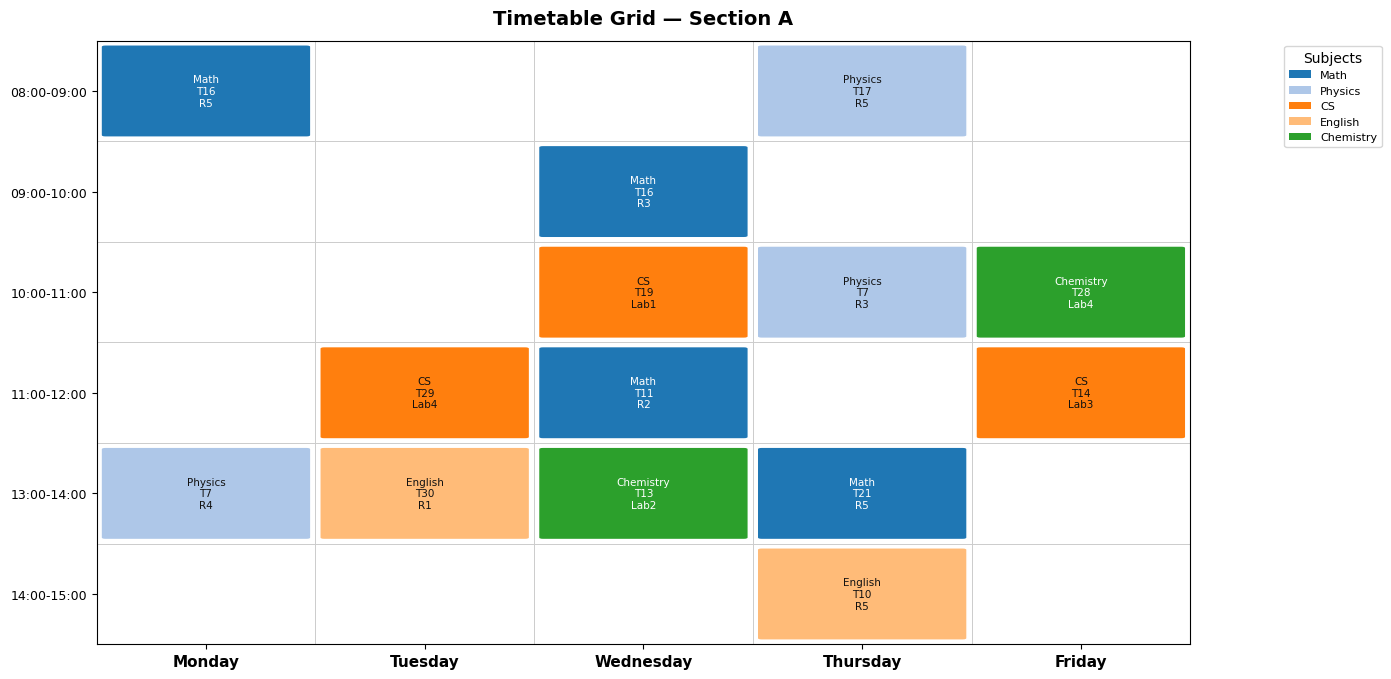

  📊 Saved → grid_section_B.png


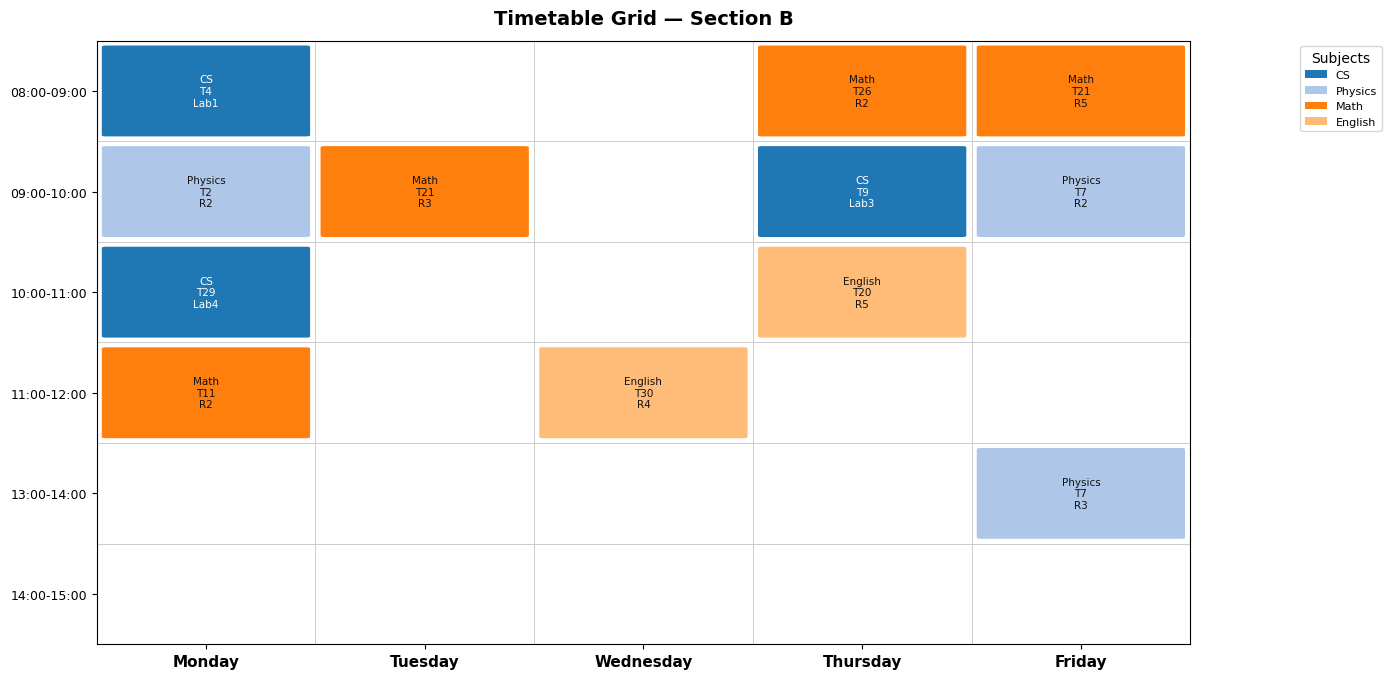

  📊 Saved → grid_section_C.png


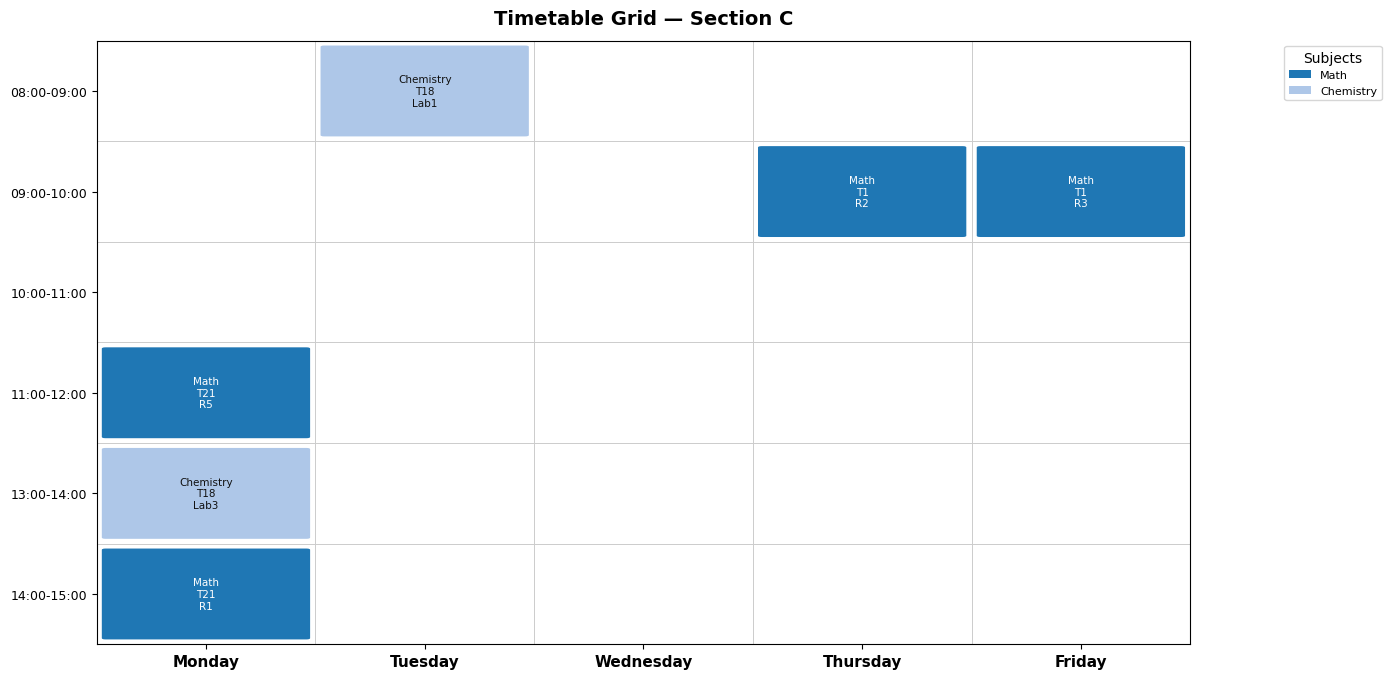

In [ ]:
def _is_dark(rgb):
    r, g, b = rgb[:3]
    return (0.299*r + 0.587*g + 0.114*b) < 0.55

def print_visual_grid(timetable_df, section_id):
    sec = timetable_df[timetable_df["Section"] == section_id].copy()
    if sec.empty:
        print(f"  No data for section {section_id}"); return
    COL_W  = 22
    TIME_W = 13
    header = f"{'Time':<{TIME_W}}" + "".join(f"{d:^{COL_W}}" for d in WORKING_DAYS)
    sep    = "-" * len(header)
    print(f"\n{'='*len(header)}")
    print(f"  TIMETABLE GRID — Section {section_id}")
    print(f"{'='*len(header)}")
    print(header); print(sep)
    for _, slot_row in TIME_SLOTS_DF.iterrows():
        t_label = slot_row["Label"]
        line    = f"{t_label:<{TIME_W}}"
        for day in WORKING_DAYS:
            match = sec[(sec["Day"] == day) & (sec["Time"] == t_label)]
            if match.empty:
                cell = "—"
            else:
                r    = match.iloc[0]
                cell = f"{r['Subject']} ({r['Teacher']}) {r['Room']}"[:COL_W-1]
            line += f"{cell:^{COL_W}}"
        print(line)
    print(sep)

def plot_visual_grid(timetable_df, section_id, save=True):
    sec = timetable_df[timetable_df["Section"] == section_id].copy()
    if sec.empty: return
    times   = TIME_SLOTS_DF["Label"].tolist()
    days    = WORKING_DAYS
    palette = plt.cm.get_cmap("tab20", 20)
    subj_color = {s: palette(i % 20) for i, s in enumerate(sec["Subject"].unique())}
    fig, ax = plt.subplots(figsize=(14, len(times)*0.9 + 1.5))
    ax.set_xlim(0, len(days)); ax.set_ylim(0, len(times))
    ax.set_xticks(np.arange(len(days)) + 0.5)
    ax.set_xticklabels(days, fontsize=11, fontweight="bold")
    ax.set_yticks(np.arange(len(times)) + 0.5)
    ax.set_yticklabels(reversed(times), fontsize=9)
    ax.set_title(f"Timetable Grid — Section {section_id}",
                 fontsize=14, fontweight="bold", pad=12)
    for _, row in sec.iterrows():
        d_idx = days.index(row["Day"])
        t_idx = len(times) - 1 - times.index(row["Time"])
        color = subj_color[row["Subject"]]
        rect  = mpatches.FancyBboxPatch(
            (d_idx+0.04, t_idx+0.06), 0.92, 0.88,
            boxstyle="round,pad=0.02", facecolor=color,
            edgecolor="white", linewidth=1.2, zorder=2)
        ax.add_patch(rect)
        label = f"{row['Subject']}\n{row['Teacher']}\n{row['Room']}"
        ax.text(d_idx+0.5, t_idx+0.5, label, ha="center", va="center",
                fontsize=7.5, color="white" if _is_dark(color) else "#111", zorder=3)
    for x in range(len(days)+1): ax.axvline(x, color="#ccc", linewidth=0.7)
    for y in range(len(times)+1): ax.axhline(y, color="#ccc", linewidth=0.7)
    handles = [mpatches.Patch(facecolor=subj_color[s], label=s)
               for s in subj_color]
    ax.legend(handles=handles, loc="upper right",
              bbox_to_anchor=(1.18, 1), fontsize=8, title="Subjects")
    plt.tight_layout()
    if save:
        fname = f"grid_section_{section_id}.png"
        plt.savefig(fname, dpi=130, bbox_inches="tight")
        print(f"  📊 Saved → {fname}")
    plt.show()

all_sections = sections["Section_ID"].tolist()
for sec in all_sections[:3]:
    print_visual_grid(timetable_df, sec)

for sec in all_sections[:3]:
    plot_visual_grid(timetable_df, sec, save=True)

## 🔴 Upgrade #2 — Conflict Checker
**Before (V1):** Violations were only counted during fitness evaluation — no post-run report.  
**After (V2):** Full validation report with per-category counts and detailed clash listing.

In [ ]:
def run_conflict_checker(chromosome):
    c = detect_conflicts(chromosome)
    print(f"\n{'='*55}")
    print("  CONFLICT CHECKER REPORT")
    print(f"{'='*55}")
    status = "✅ VALID — No conflicts" if c["total"] == 0 else "⚠️  CONFLICTS FOUND"
    print(f"  Status            : {status}")
    print(f"  Total Conflicts   : {c['total']}")
    print(f"  Teacher Clashes   : {c['teacher_clashes']}  (same teacher, same day+slot)")
    print(f"  Room Clashes      : {c['room_clashes']}  (same room, same day+slot)")
    print(f"  Section Clashes   : {c['section_clashes']}  (same section, same day+slot)")
    print(f"  Max-cls violations: {c['day_violations']}  (teacher > {MAX_TEACHER_CLASSES_PER_DAY} cls/day)")
    print(f"{'='*55}")
    if c["total"] > 0:
        print("\n  Detailed clashes:")
        teacher_slots = defaultdict(list)
        for gene in chromosome:
            teacher_slots[(gene["teacher"], gene["day"], gene["slot"])].append(gene)
        for key, genes in teacher_slots.items():
            if len(genes) > 1:
                tid, day, slot = key
                classes = ", ".join(f"{g['section']}/{g['subject']}" for g in genes)
                print(f"  ⚡ Teacher {tid} | {day} {SLOT_LABEL[slot]} | {classes}")
        room_slots = defaultdict(list)
        for gene in chromosome:
            room_slots[(gene["room"], gene["day"], gene["slot"])].append(gene)
        for key, genes in room_slots.items():
            if len(genes) > 1:
                room, day, slot = key
                classes = ", ".join(f"{g['section']}/{g['subject']}" for g in genes)
                print(f"  🏫 Room {room} | {day} {SLOT_LABEL[slot]} | {classes}")
    return c

conflict_report = run_conflict_checker(best_chrom)


  CONFLICT CHECKER REPORT
  Status            : ✅ VALID — No conflicts
  Total Conflicts   : 0
  Teacher Clashes   : 0  (same teacher, same day+slot)
  Room Clashes      : 0  (same room, same day+slot)
  Section Clashes   : 0  (same section, same day+slot)
  Max-cls violations: 0  (teacher > 4 cls/day)


## 🟣 Upgrade #3 — Performance Metrics
**Before (V1):** 5 metrics — fitness, violations, fuzzy score, improvement %, initial fitness.  
**After (V2):** 8 metrics — adds **convergence generation**, **execution time**, and **avg gain/gen**.

In [ ]:
def performance_metrics(best_chrom, teachers_df, best_hist,
                        avg_hist, viol_hist, exec_time):
    final_fit, final_viol = fitness(best_chrom, teachers_df)
    fuzzy_s   = evaluate_fuzzy(best_chrom, teachers_df)
    init_fit  = best_hist[0]
    conv_gen  = next((i for i, v in enumerate(viol_hist) if v == 0), NUM_GENERATIONS)
    fit_range = best_hist[-1] - best_hist[0]
    gens_run  = len(best_hist)
    improvement_pct = (fit_range / max(init_fit, 1)) * 100

    print(f"\n{'='*60}")
    print("  PERFORMANCE METRICS")
    print(f"{'='*60}")
    print(f"  Final Fitness Score         : {final_fit:.2f}")
    print(f"  Hard Constraint Violations  : {final_viol}")
    print(f"  Fuzzy Soft Score            : {fuzzy_s:.2f} / 10")
    print(f"  Initial Fitness             : {init_fit:.2f}")
    print(f"  Generations Run             : {gens_run}")
    print(f"  Convergence Generation      : {conv_gen}  (first gen with 0 violations)")
    print(f"  Fitness Improvement         : {improvement_pct:+.1f}%")
    print(f"  Execution Time              : {exec_time:.2f} s")
    print(f"  Avg fitness gain / gen      : {fit_range / max(gens_run,1):.3f}")
    print(f"{'='*60}")
    return {"final_fitness": round(final_fit,2), "violations": final_viol,
            "fuzzy_score": round(fuzzy_s,2), "initial_fitness": round(init_fit,2),
            "generations": gens_run, "convergence_gen": conv_gen,
            "improvement_pct": round(improvement_pct,1), "exec_time_s": round(exec_time,2)}

conv_gen = next((i for i, v in enumerate(viol_hist) if v == 0), NUM_GENERATIONS)
metrics  = performance_metrics(best_chrom, teachers, best_hist,
                                avg_hist, viol_hist, exec_time)


  PERFORMANCE METRICS
  Final Fitness Score         : 1083.33
  Hard Constraint Violations  : 0
  Fuzzy Soft Score            : 8.33 / 10
  Initial Fitness             : 465.31
  Generations Run             : 150
  Convergence Generation      : 20  (first gen with 0 violations)
  Fitness Improvement         : +132.8%
  Execution Time              : 220.89 s
  Avg fitness gain / gen      : 4.120


## 🔵 Upgrade #4 — Fitness Graph
**Before (V1):** Simple line plot, no annotations.  
**After (V2):** Shaded area between best/avg curves, convergence marker, peak annotation, violation area fill.

  📊 Saved → fitness_graph.png


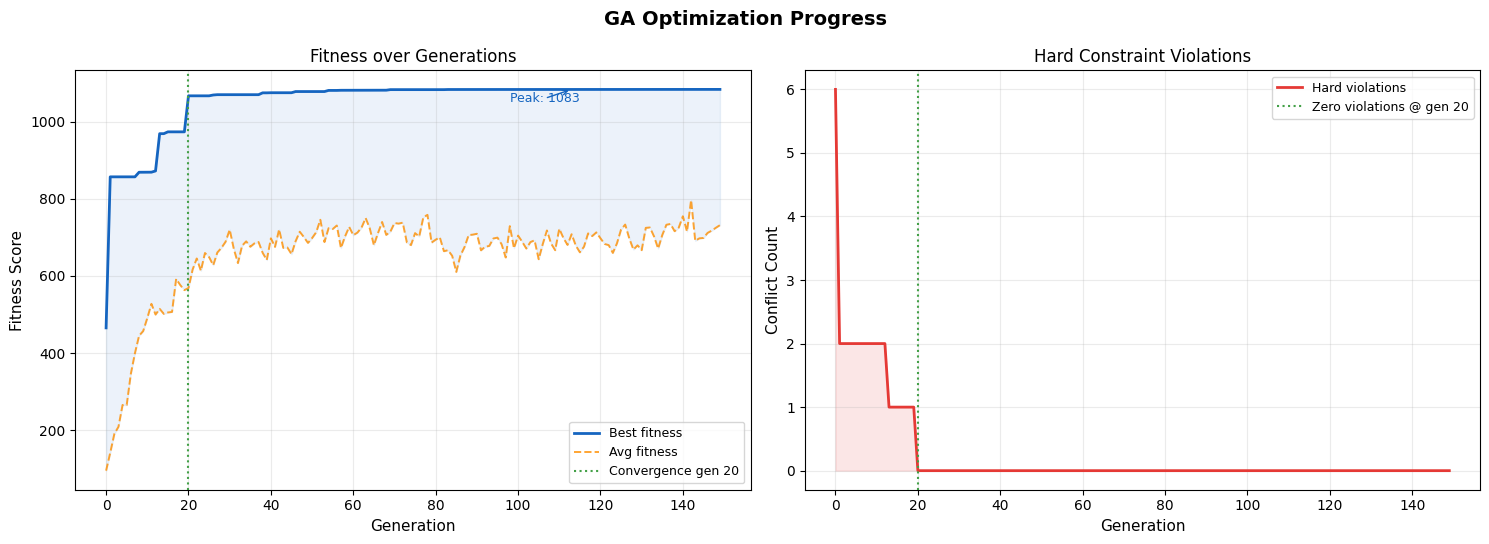

In [ ]:
def plot_fitness_graph(best_hist, avg_hist, viol_hist, conv_gen, save=True):
    gens = list(range(len(best_hist)))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    fig.suptitle("GA Optimization Progress", fontsize=14, fontweight="bold")

    ax = axes[0]
    ax.plot(gens, best_hist, color="#1565C0", linewidth=2,   label="Best fitness")
    ax.plot(gens, avg_hist,  color="#FF8F00", linewidth=1.4,
            linestyle="--", label="Avg fitness", alpha=0.8)
    ax.fill_between(gens, avg_hist, best_hist, alpha=0.08, color="#1565C0")
    ax.axvline(conv_gen, color="#43A047", linewidth=1.5,
               linestyle=":", label=f"Convergence gen {conv_gen}")
    ax.set_xlabel("Generation", fontsize=11); ax.set_ylabel("Fitness Score", fontsize=11)
    ax.set_title("Fitness over Generations", fontsize=12)
    ax.legend(fontsize=9); ax.grid(alpha=0.25)
    ax.annotate(f"Peak: {max(best_hist):.0f}",
                xy=(np.argmax(best_hist), max(best_hist)),
                xytext=(np.argmax(best_hist) - len(gens)*0.1, max(best_hist)*0.97),
                arrowprops=dict(arrowstyle="->", color="#1565C0"),
                fontsize=9, color="#1565C0")

    ax2 = axes[1]
    ax2.plot(gens, viol_hist, color="#E53935", linewidth=2, label="Hard violations")
    ax2.fill_between(gens, 0, viol_hist, alpha=0.12, color="#E53935")
    if conv_gen < len(gens):
        ax2.axvline(conv_gen, color="#43A047", linewidth=1.5,
                    linestyle=":", label=f"Zero violations @ gen {conv_gen}")
    ax2.set_xlabel("Generation", fontsize=11); ax2.set_ylabel("Conflict Count", fontsize=11)
    ax2.set_title("Hard Constraint Violations", fontsize=12)
    ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

    plt.tight_layout()
    if save:
        plt.savefig("fitness_graph.png", dpi=130, bbox_inches="tight")
        print("  📊 Saved → fitness_graph.png")
    plt.show()

plot_fitness_graph(best_hist, avg_hist, viol_hist, conv_gen, save=True)

## 📊 Step 16 — Teacher Workload & Heatmap

  📊 Saved → teacher_workload.png


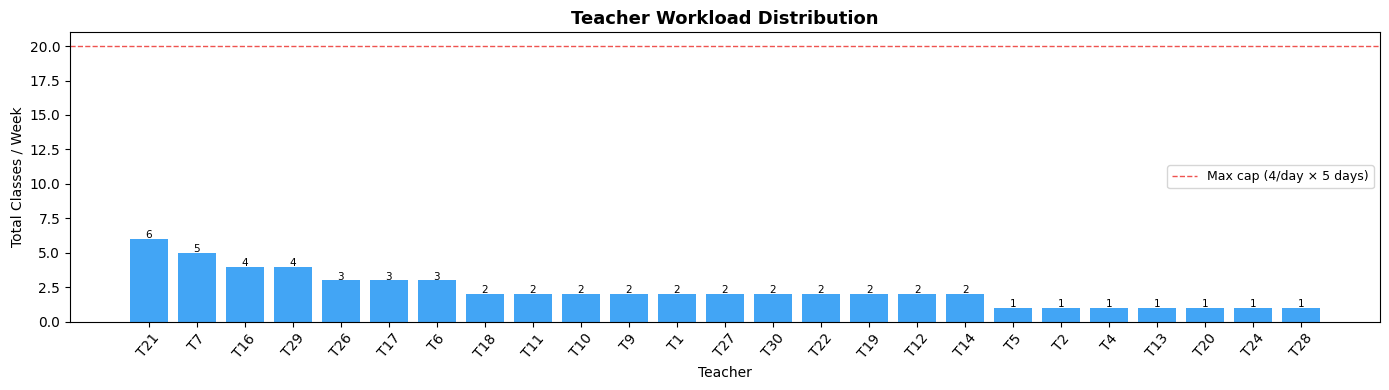

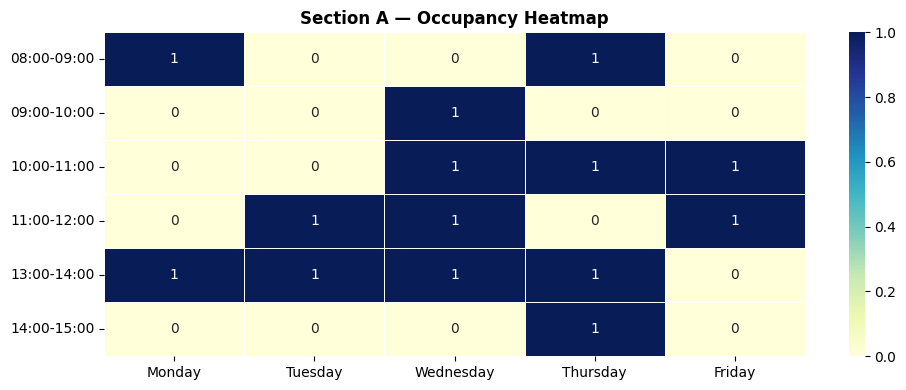

In [ ]:
def plot_teacher_workload(timetable_df, save=True):
    load = timetable_df["Teacher"].value_counts().reset_index()
    load.columns = ["Teacher", "Classes"]
    fig, ax = plt.subplots(figsize=(14, 4))
    colors  = ["#EF5350" if v > MAX_TEACHER_CLASSES_PER_DAY * 5
               else "#42A5F5" for v in load["Classes"]]
    bars    = ax.bar(load["Teacher"], load["Classes"], color=colors)
    ax.axhline(MAX_TEACHER_CLASSES_PER_DAY * 5, color="#EF5350",
               linestyle="--", linewidth=1,
               label=f"Max cap ({MAX_TEACHER_CLASSES_PER_DAY}/day × 5 days)")
    ax.set_xlabel("Teacher"); ax.set_ylabel("Total Classes / Week")
    ax.set_title("Teacher Workload Distribution", fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=50); ax.legend(fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(int(bar.get_height())), ha="center", fontsize=7.5)
    plt.tight_layout()
    if save: plt.savefig("teacher_workload.png", dpi=130, bbox_inches="tight"); print("  📊 Saved → teacher_workload.png")
    plt.show()

def plot_section_heatmap(timetable_df, section_id, save=True):
    sec  = timetable_df[timetable_df["Section"] == section_id].copy()
    if sec.empty: return
    times = TIME_SLOTS_DF["Label"].tolist()
    heat  = pd.DataFrame(0, index=times, columns=WORKING_DAYS)
    for _, row in sec.iterrows():
        if row["Time"] in heat.index:
            heat.loc[row["Time"], row["Day"]] += 1
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(heat, cmap="YlGnBu", linewidths=0.5, linecolor="white",
                annot=True, fmt="d", ax=ax)
    ax.set_title(f"Section {section_id} — Occupancy Heatmap", fontweight="bold")
    plt.tight_layout()
    if save: plt.savefig(f"heatmap_{section_id}.png", dpi=130, bbox_inches="tight")
    plt.show()

plot_teacher_workload(timetable_df, save=True)
plot_section_heatmap(timetable_df, all_sections[0], save=True)

## 💾 Step 17 — Download Output Files

In [ ]:
from google.colab import files
import os

output_files = [
    "final_timetable.csv",
    "final_timetable.xlsx",
    "fitness_graph.png",
    "teacher_workload.png",
]
output_files += [f"grid_section_{s}.png" for s in all_sections[:3]]
output_files += [f"heatmap_{all_sections[0]}.png"]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f"⬇️  Downloaded: {f}")
    else:
        print(f"⚠️  Not found: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloaded: final_timetable.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  Downloaded: grid_section_C.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloaded: heatmap_A.png
